# 实验三：频域图像增强（实现版）

1. 显示原图与傅里叶频谱（对数增强）
2. 理想低通/高通滤波对比（不同 `D0`）
3. 巴特沃斯低通/高通滤波对比（不同 `D0`）
4. 高斯低通/高通滤波对比（不同 `D0`）
5. 巴特沃斯不同阶数 `n` 对比

> 默认在 Jupyter 中显示结果；若需要保存图片，把 `SAVE_RESULTS` 设为 `True`。


In [22]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def find_project_root() -> Path:
    """向上查找包含 Experiment_GUET 的目录，兼容不同 cwd。"""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Experiment_GUET').exists():
            return p
    raise FileNotFoundError("未找到包含 'Experiment_GUET' 的项目根目录")


PROJECT_ROOT = find_project_root()
PIC_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'pic'
SRC_IMG_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / 'class_img'

# 默认测试图：实验内容里的汽车图
IMAGE_PATH = PIC_DIR / 'car.jpg'

# 是否保存输出图
SAVE_RESULTS = False
OUT_DIR = PROJECT_ROOT / 'Experiment_GUET' / 'src' / '实验三' / 'results'
if SAVE_RESULTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)


def read_gray(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"图像不存在: {path}")
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"OpenCV 无法读取图像: {path}")
    return img


In [ ]:
def fft2_image(image):
    """对图像进行二维傅里叶变换，并进行频谱中心化"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.float64(image)
    F = np.fft.fft2(f)
    Fshift = np.fft.fftshift(F)
    return Fshift


def ifft2_image(Fshift):
    """逆傅里叶变换，返回用于显示的空域 uint8（min-max 拉伸，高通/锐化时避免负值被 clip 掉）。"""
    F = np.fft.ifftshift(Fshift)
    f = np.fft.ifft2(F)
    img = np.real(f)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(img)


def get_distance_matrix(M, N):
    """D(u,v)：与 fftshift 对齐，为各频率点到中心 (M/2, N/2) 的欧氏距离（Gonzalez 定义）。"""
    row = np.arange(M, dtype=np.float64)[:, None] - M / 2.0
    col = np.arange(N, dtype=np.float64)[None, :] - N / 2.0
    return np.sqrt(row**2 + col**2)


def ideal_lowpass(M, N, D0):
    """理想低通滤波器"""
    D = get_distance_matrix(M, N)
    H = np.double(D <= D0)
    return H


def ideal_highpass(M, N, D0):
    """理想高通滤波器"""
    D = get_distance_matrix(M, N)
    H = np.double(D > D0)
    return H


def butterworth_lowpass(M, N, D0, n=2):
    """巴特沃斯低通滤波器"""
    D = get_distance_matrix(M, N)
    H = 1 / (1 + (D / D0)**(2*n))
    return H


def butterworth_highpass(M, N, D0, n=2):
    """巴特沃斯高通滤波器"""
    D = get_distance_matrix(M, N)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = 1 / (1 + (D0 / D) ** (2 * n))
    H = np.nan_to_num(H, nan=0.0, posinf=0.0, neginf=0.0)
    H[D == 0] = 0.0
    return H


def gaussian_lowpass(M, N, D0):
    """高斯低通滤波器"""
    D = get_distance_matrix(M, N)
    H = np.exp(-(D**2) / (2 * D0**2))
    return H


def gaussian_highpass(M, N, D0):
    """高斯高通滤波器"""
    D = get_distance_matrix(M, N)
    H = 1 - np.exp(-(D**2) / (2 * D0**2))
    return H


def display_spectrum(Fshift):
    """显示频谱（对数变换增强可视化）"""
    magnitude = np.abs(Fshift)
    magnitude_log = np.log(1 + magnitude)
    #magnitude_log = magnitude
    magnitude_norm = cv2.normalize(magnitude_log, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(magnitude_norm)


In [24]:
def BWBand(w, h):
    img = np.zeros([321, 201], dtype=np.uint8)
    # 计算中心坐标
    center_row = 321 // 2 
    center_col = 201 // 2 
    start_y = center_row - h // 2  # 上
    end_y = center_row + h // 2    # 下
    start_x = center_col - w // 2  # 左
    end_x = center_col + w // 2    # 右
    img[start_y:end_y, start_x:end_x] = 255
    return img

## 按实验任务执行

- 实验1：原图与频谱
- 实验2-7：6类低/高通滤波器在不同截止频率 `D0` 下对比
- 实验8：巴特沃斯不同阶数 `n` 对比


实验1：原图与频谱


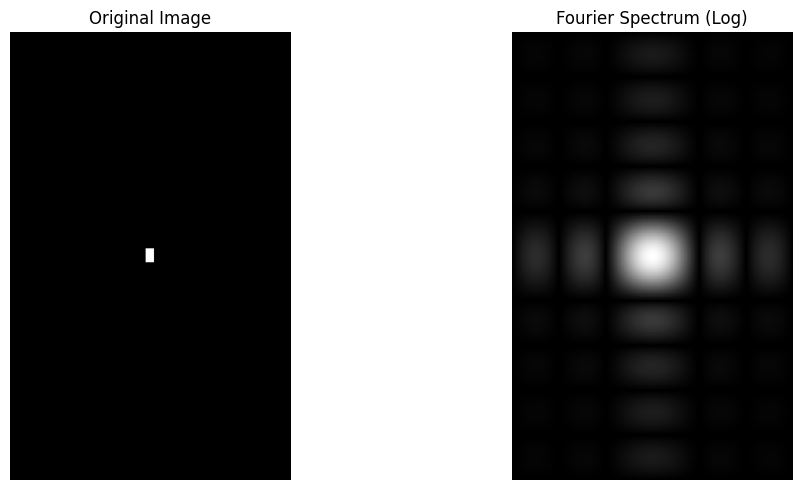

输入图像: /home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/pic/car.jpg
图像尺寸: 343 x 550

理想低通: D0=[30, 60, 120] 对比


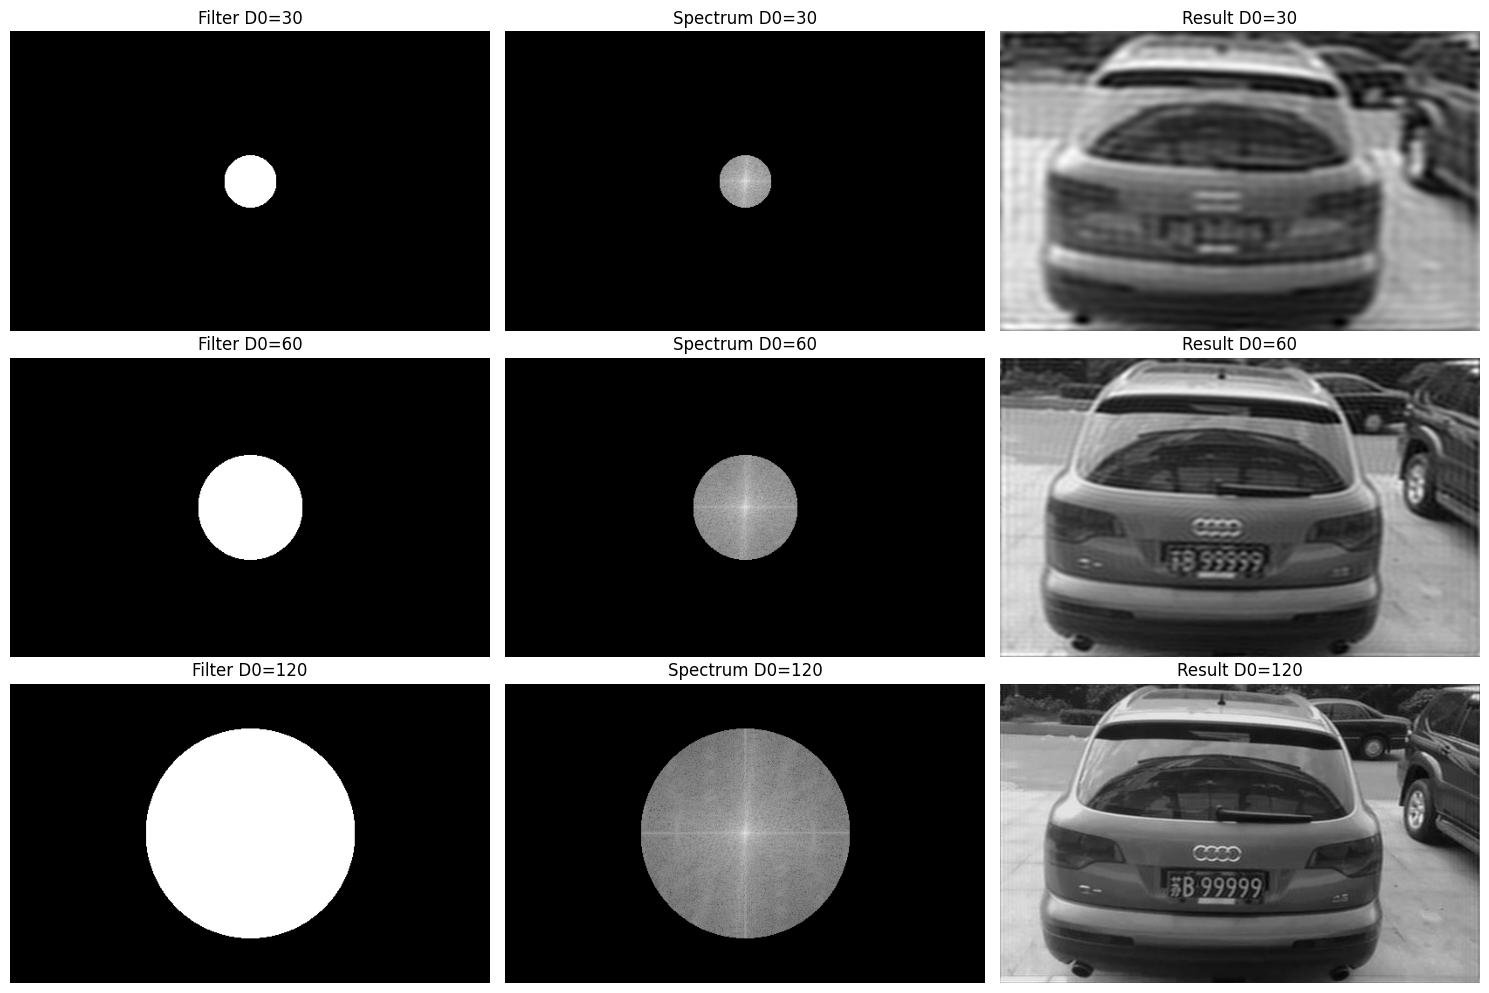


理想高通: D0=[30, 60, 120] 对比


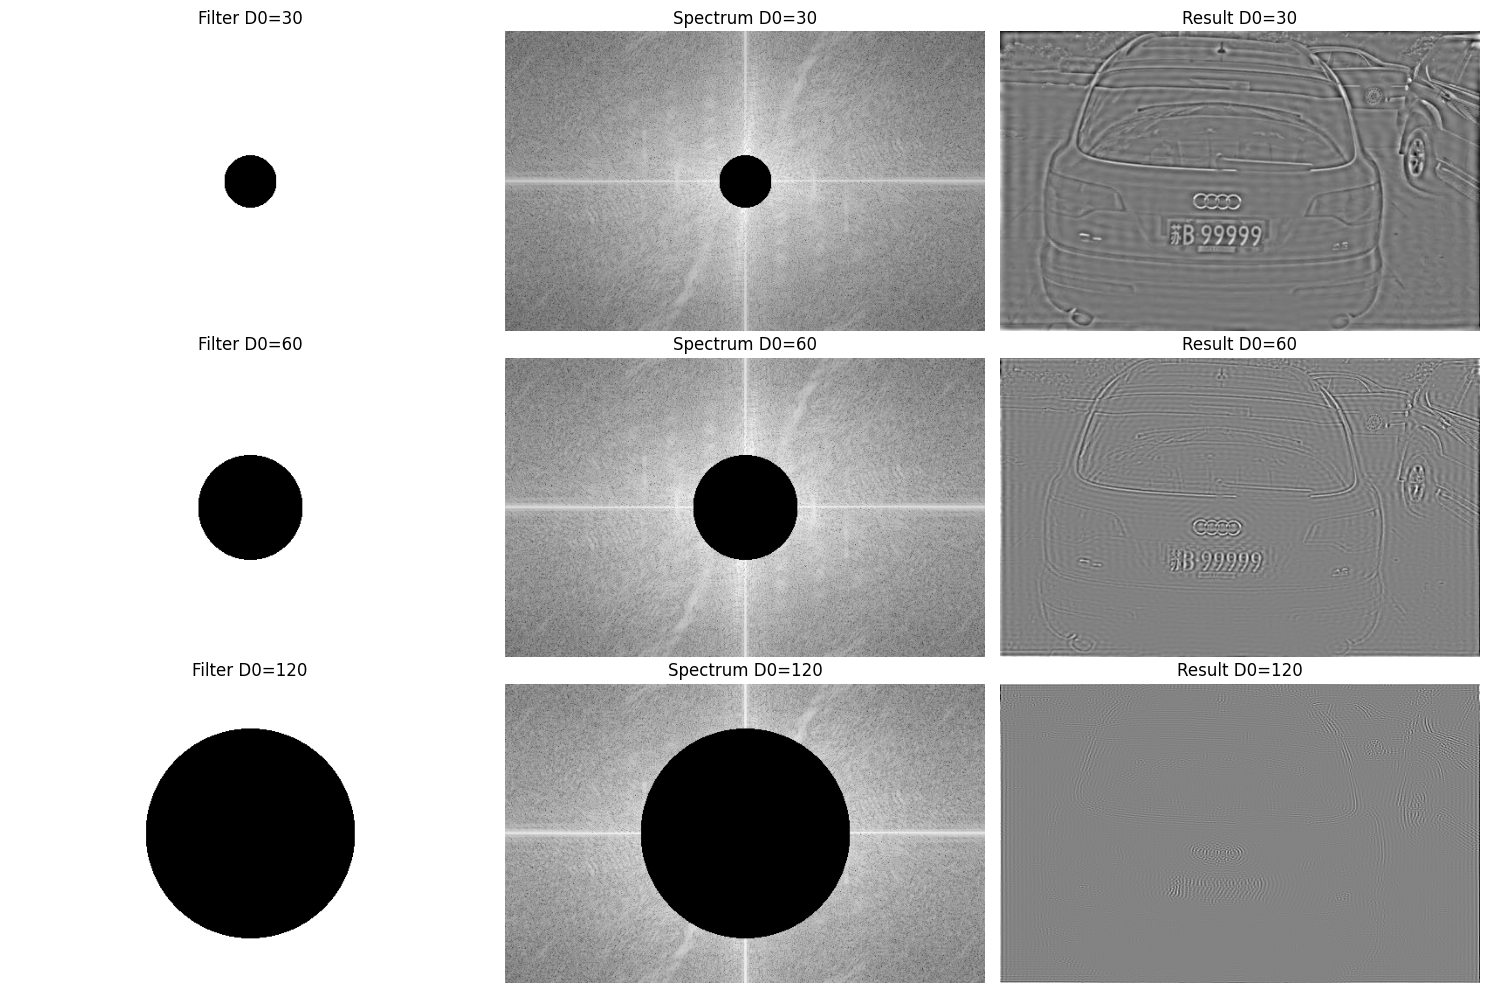


巴特沃斯低通(n=2): D0=[30, 60, 120] 对比


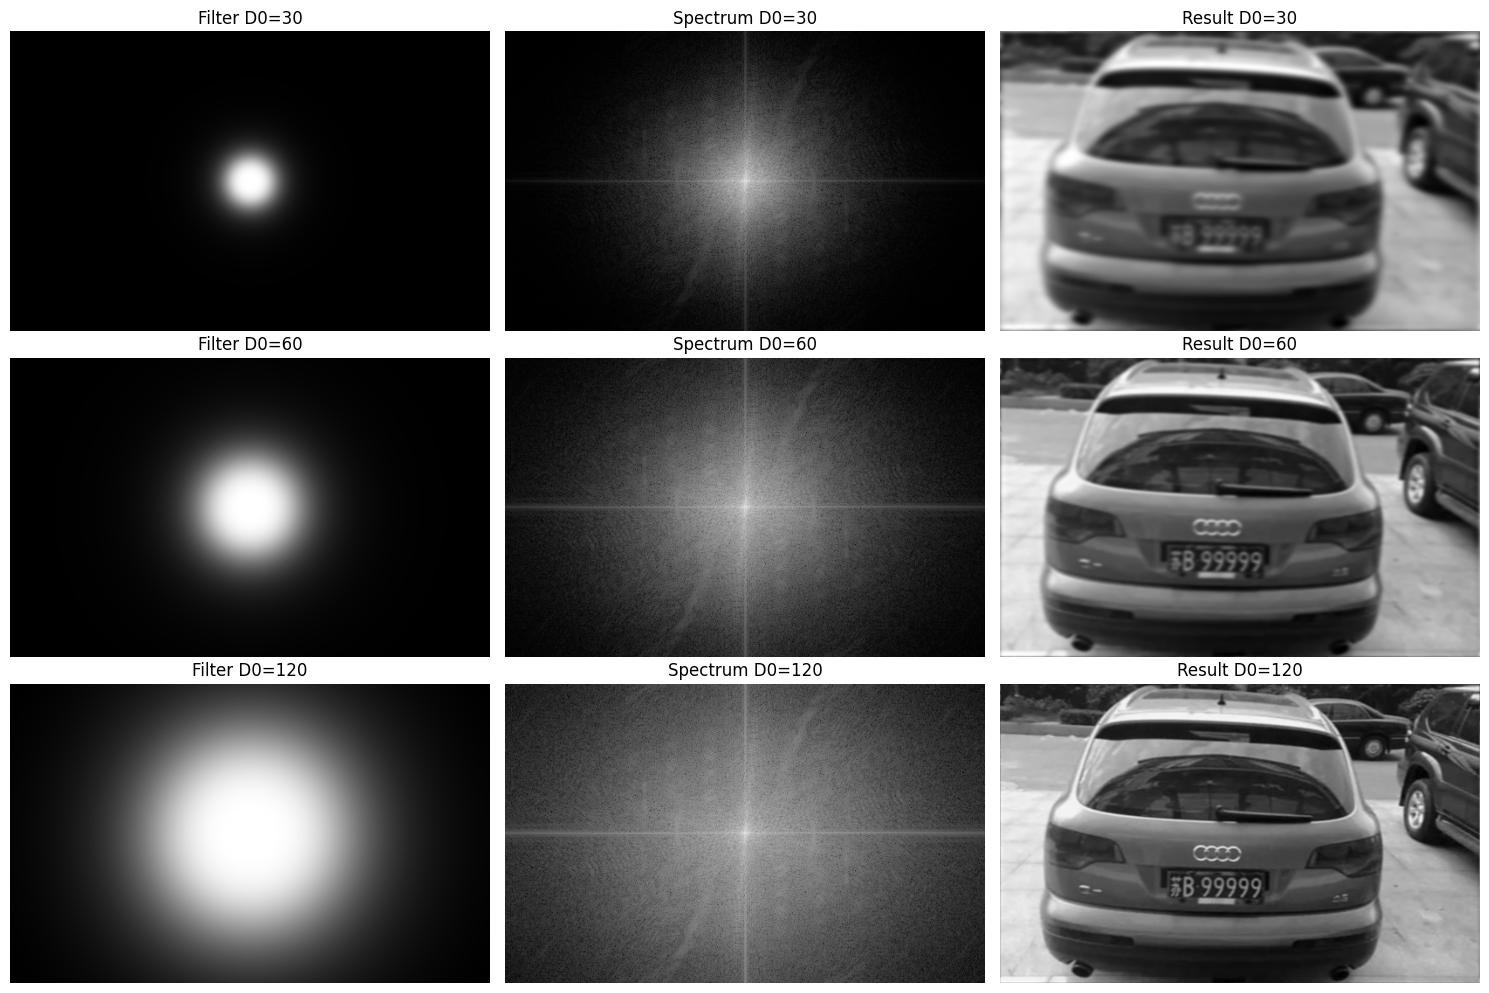


巴特沃斯高通(n=2): D0=[30, 60, 120] 对比


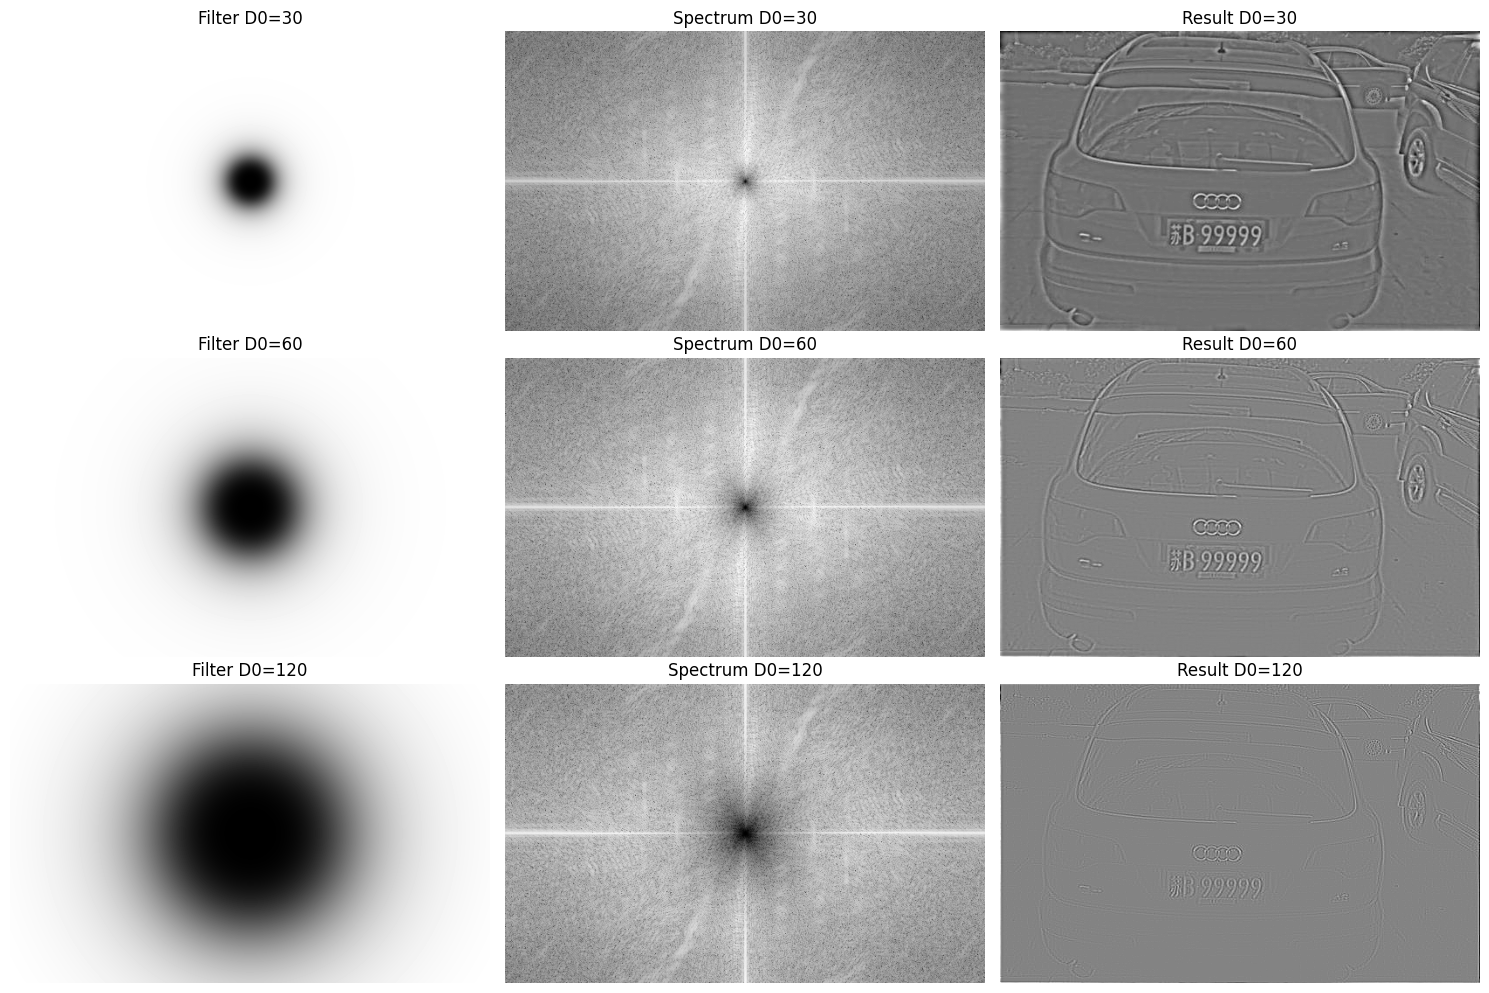


高斯低通: D0=[30, 60, 120] 对比


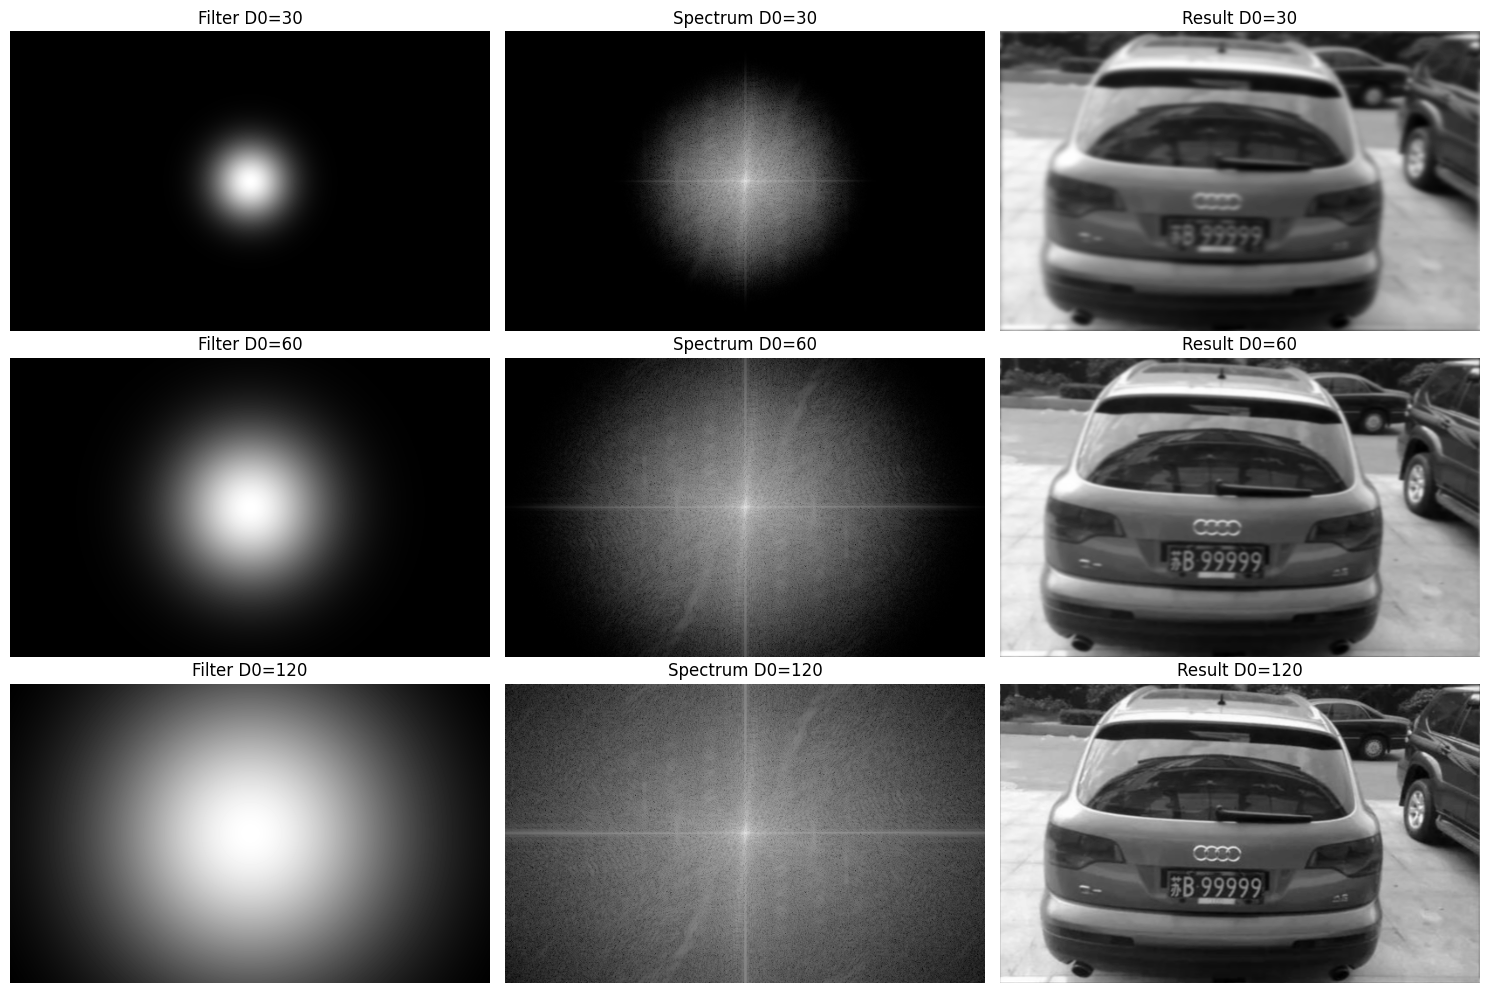


高斯高通: D0=[30, 60, 120] 对比


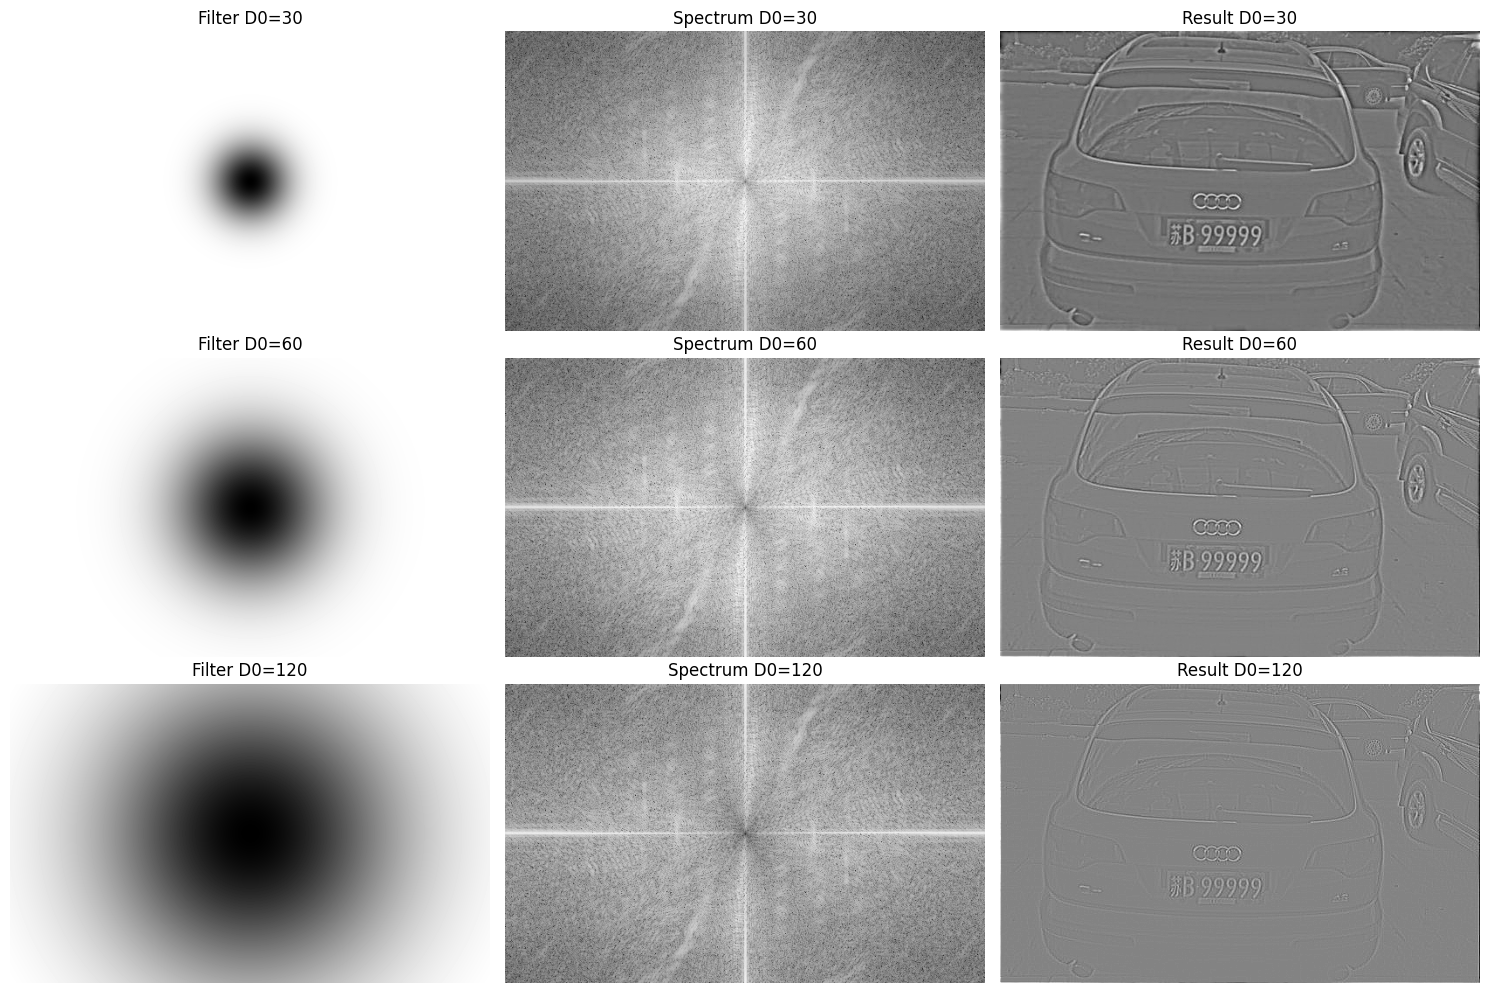


实验8：巴特沃斯不同阶数对比


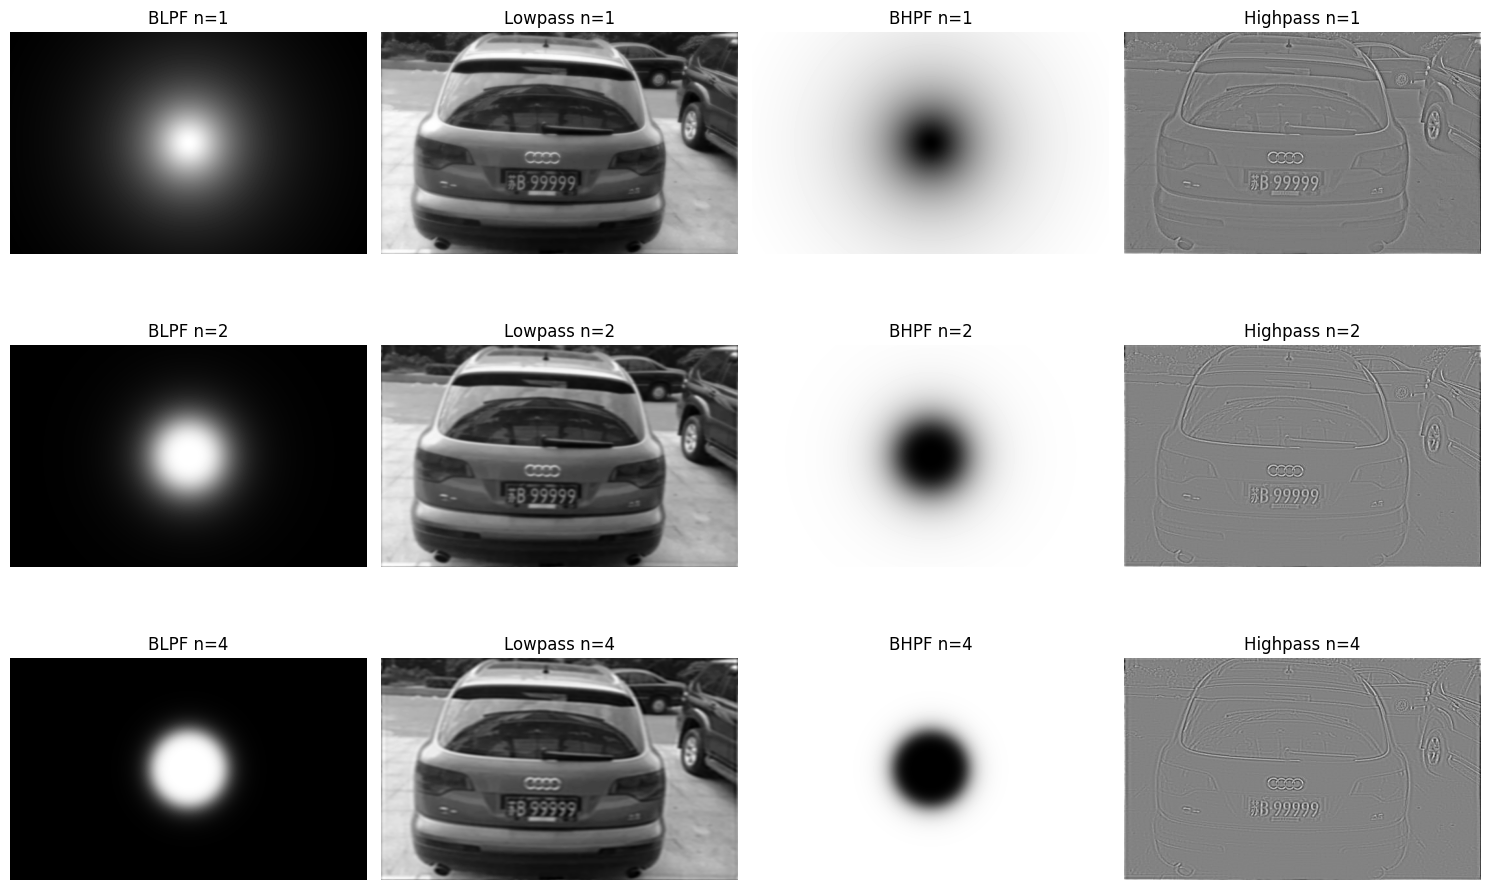


实验完成。


In [25]:

img = BWBand(7,11)


# 傅里叶中心化频谱
Fshift = fft2_image(img)


# 实验1：原图与频谱
print("\n实验1：原图与频谱")
spectrum = display_spectrum(Fshift)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(spectrum, cmap='gray')
axes[1].set_title('Fourier Spectrum (Log)')
axes[1].axis('off')
plt.tight_layout()
if SAVE_RESULTS:
    plt.savefig(OUT_DIR / '01_original_and_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# 实验输入
img = read_gray(IMAGE_PATH)
M, N = img.shape
print(f"输入图像: {IMAGE_PATH}")
print(f"图像尺寸: {M} x {N}")
Fshift = fft2_image(img)


# 实验2-7：理想/巴特沃斯/高斯低高通（D0 对比）
D0_values = [30, 60, 120]
filters = [
    ('理想低通', ideal_lowpass),
    ('理想高通', ideal_highpass),
    ('巴特沃斯低通(n=2)', lambda m, n, d0: butterworth_lowpass(m, n, d0, 2)),
    ('巴特沃斯高通(n=2)', lambda m, n, d0: butterworth_highpass(m, n, d0, 2)),
    ('高斯低通', gaussian_lowpass),
    ('高斯高通', gaussian_highpass),
]

for name, filter_func in filters:
    print(f"\n{name}: D0={D0_values} 对比")
    plt.figure(figsize=(15, 10))
    for i, D0 in enumerate(D0_values):
        H = filter_func(M, N, D0)
        G = Fshift * H
        result = ifft2_image(G)

        plt.subplot(3, 3, i * 3 + 1)
        plt.imshow(H, cmap='gray')
        plt.title(f'Filter D0={D0}')
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 2)
        plt.imshow(np.log(1 + np.abs(G)), cmap='gray')
        plt.title(f'Spectrum D0={D0}')
        plt.axis('off')

        plt.subplot(3, 3, i * 3 + 3)
        plt.imshow(result, cmap='gray')
        plt.title(f'Result D0={D0}')
        plt.axis('off')

    plt.tight_layout()
    if SAVE_RESULTS:
        safe_name = name.replace('(', '_').replace(')', '').replace('=', '_').replace('/', '_')
        plt.savefig(OUT_DIR / f"{safe_name}.png", dpi=150, bbox_inches='tight')
    plt.show()


# 实验8：巴特沃斯不同阶数 n 对比（低通与高通）
print("\n实验8：巴特沃斯不同阶数对比")
D0 = 60
n_values = [1, 2, 4]

plt.figure(figsize=(15, 10))
for i, n in enumerate(n_values):
    H_lp = butterworth_lowpass(M, N, D0, n)
    G_lp = Fshift * H_lp
    result_lp = ifft2_image(G_lp)

    H_hp = butterworth_highpass(M, N, D0, n)
    G_hp = Fshift * H_hp
    result_hp = ifft2_image(G_hp)

    plt.subplot(3, 4, i * 4 + 1)
    plt.imshow(H_lp, cmap='gray')
    plt.title(f'BLPF n={n}')
    plt.axis('off')

    plt.subplot(3, 4, i * 4 + 2)
    plt.imshow(result_lp, cmap='gray')
    plt.title(f'Lowpass n={n}')
    plt.axis('off')

    plt.subplot(3, 4, i * 4 + 3)
    plt.imshow(H_hp, cmap='gray')
    plt.title(f'BHPF n={n}')
    plt.axis('off')

    plt.subplot(3, 4, i * 4 + 4)
    plt.imshow(result_hp, cmap='gray')
    plt.title(f'Highpass n={n}')
    plt.axis('off')

plt.tight_layout()
if SAVE_RESULTS:
    plt.savefig(OUT_DIR / '08_butterworth_order_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n实验完成。")
if SAVE_RESULTS:
    print(f"结果已保存到: {OUT_DIR}")
